In [1]:
import torch

print(torch.__version__)
import numpy as np
from numpy import pi
from scipy.spatial.transform import Rotation as R
import matplotlib.pyplot as plt

2.3.1+cu121


In [2]:
# Check if CUDA is available
if torch.cuda.is_available():
    print("CUDA is available. Number of CUDA devices:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")
        print(f"  - Capability: {torch.cuda.get_device_capability(i)}")
        print(f"  - Memory Allocated: {torch.cuda.memory_allocated(i)} bytes")
        print(f"  - Memory Cached: {torch.cuda.memory_reserved(i)} bytes")
else:
    print("CUDA is not available.")

CUDA is available. Number of CUDA devices: 1
Device 0: NVIDIA GeForce RTX 4060 Laptop GPU
  - Capability: (8, 9)
  - Memory Allocated: 0 bytes
  - Memory Cached: 0 bytes


# Section 0: Proofs of concepts with quaternions and integration of rotations. 

In [3]:
# r = R.from_quat([0, 0, 1, 2])
# r_hat = r.as_euler('zyx', degrees=False)
# R.from_euler('zyx', r_hat, degrees=False).as_quat()

In [4]:
# def plot_rotated_axes(ax, r, name=None, offset=(0, 0, 0), scale=1):
#     colors = ("#FF6666", "#005533", "#1199EE")  # Colorblind-safe RGB
#     loc = np.array([offset, offset])
#     for i, (axis, c) in enumerate(zip((ax.xaxis, ax.yaxis, ax.zaxis),
#                                       colors)):
#         axlabel = axis.axis_name
#         axis.set_label_text(axlabel)
#         axis.label.set_color(c)
#         axis.line.set_color(c)
#         axis.set_tick_params(colors=c)
#         line = np.zeros((2, 3))
#         line[1, i] = scale
#         line_rot = r.apply(line)
#         line_plot = line_rot + loc
#         ax.plot(line_plot[:, 0], line_plot[:, 1], line_plot[:, 2], c)
#         text_loc = line[1]*1.2
#         text_loc_rot = r.apply(text_loc)
#         text_plot = text_loc_rot + loc[0]
#         ax.text(*text_plot, axlabel.upper(), color=c,
#                 va="center", ha="center")
#     ax.text(*offset, name, color="k", va="center", ha="center",
#             bbox={"fc": "w", "alpha": 0.8, "boxstyle": "circle"})

In [5]:
# r0 = R.identity()
# r1 = R.from_euler("ZYX", [90, -30, 0], degrees=True)  # intrinsic
# r2 = R.from_euler("zyx", [90, -30, 0], degrees=True)  # extrinsic
# 
# ax = plt.figure().add_subplot(projection="3d", proj_type="ortho")
# plot_rotated_axes(ax, r0, name="r0", offset=(0, 0, 0))
# plot_rotated_axes(ax, r1, name="r1", offset=(3, 0, 0))
# plot_rotated_axes(ax, r2, name="r2", offset=(6, 0, 0))
# _ = ax.annotate(
#     "r0: Identity Rotation\n"
#     "r1: Intrinsic Euler Rotation (ZYX)\n"
#     "r2: Extrinsic Euler Rotation (zyx)",
#     xy=(0.6, 0.7), xycoords="axes fraction", ha="left"
# )
# ax.set(xlim=(-1.25, 7.25), ylim=(-1.25, 1.25), zlim=(-1.25, 1.25))
# ax.set(xticks=range(-1, 8), yticks=[-1, 0, 1], zticks=[-1, 0, 1])
# ax.set_aspect("equal", adjustable="box")
# ax.figure.set_size_inches(6, 5)
# plt.tight_layout()

In [6]:
# r0 = R.from_quat([0, 0, 0, 1])
# r1_q = [1, 0, 0, 0]
# r2_q = [0, 1, 0, 0]
# r1 = R.from_quat(r1_q)
# r2 = R.from_quat(r2_q)
# 
# print((r0 * r1 * r2).as_quat())
# print((r2 * r1 * r0).as_quat())

In [7]:
import Rotations as Rot

In [8]:
# angular_displacements = torch.tensor([[0.1, 0.2, 0.3], [0.0, pi, 0.0]])  # Example tensor of angular displacements
# rotations = Rot.exp_quat(angular_displacements)
# 
# print(rotations)

In [9]:
# torch.device("cuda:0")

# Training Task 0.1q and 0.2q

## Generating datasets


In [1]:
from utils import goto_project_root
from utils.path_settings import MODEL_SAVE_PATH, DATA_PATH, LOG_PATH
from torch.utils.tensorboard import SummaryWriter
import SimulateDatasets.GenTrainingData as g
from utils import create_splits, get_dataloaders, force_remove_dir
from Network_models import Trainer as t
from importlib import reload
import os
reload(t)
reload(g)
import time
import torch
import numpy as np
from pytorch3d.transforms import so3_relative_angle
from pytorch3d.transforms import quaternion_to_matrix

In [4]:
cell_type = "GRU"
seq_len = 100
prep_phase = 50
configs = {
    "model_specs": {
        "model_name": "CustomRNN", # To diffrentiate from the several types of RNN cells.
        "model_path": "Network_models.RNN_models",
        "model_params": {
            "input_size": 8,
            "hidden_size": 8,
            "num_layers": 1,
            "output_size": 3,
            "cell_type": cell_type,
        }
    },
    "model_id": "lean",
    "device": "cuda",
    "optimizer_specs": {
        "optimizer_name": "Adam",
        "optimizer_params": {
            "lr": 0.001
        }
    },

    "distance_loss": "geodesic_gradual",
    "gradual_loss_weighting": lambda t_current: (t_current + 1)/(seq_len - prep_phase),
    "regularisation_loss": "L2",
    "distance_weight": 0.9,

    "save_path": MODEL_SAVE_PATH + f"\\{cell_type}_model",
    "log_path": LOG_PATH,
    "check_path": MODEL_SAVE_PATH + f"\\{cell_type}_model_checkpoints",

    "training_config": {
        "task_id": "0.2q",
        "batch_size": 128,
        "mini_batch_size": 32,
        "seq_len": seq_len,
        "prep_phase": prep_phase,
    }
}

configs["training_config"]["data_save_path"] = DATA_PATH + ("\\Data_" + configs["training_config"]["task_id"] + "_" + 
                                                            configs["model_id"]+ ".pth")
configs["save_path"] = configs["save_path"] + ("_" + configs["training_config"]["task_id"] + "_" + configs["model_id"])
configs["check_path"] = configs["check_path"] + ("_" + configs["training_config"]["task_id"] + "_" + configs["model_id"])
configs["log_path"] = configs["log_path"] + ("\\Log_" + configs["training_config"]["task_id"] + "_" + configs["model_id"])
if configs["distance_loss"][-7:] == "gradual":
    configs["save_path"] = configs["save_path"] + "_gradual"
    configs["check_path"] = configs["check_path"] + "_gradual"
    configs["log_path"] = configs["log_path"] + "_gradual"
    configs["model_specs"]["model_params"]["stepwise"] = True
else:
    configs["model_specs"]["model_params"]["stepwise"] = False

for path in [configs["save_path"], configs["check_path"], configs["log_path"]]:
    os.makedirs(path, exist_ok=True)
    
data1 = g.gen_training_data(configs['training_config'])
dataloaders = get_dataloaders(data1, batch_size=configs["training_config"]["mini_batch_size"], k=5)

In [5]:
configs["save_path"]

'D:\\Projects\\mental-rotations\\models\\GRU_model_0.2q_lean_gradual'

In [18]:
rnn_trainer = t.Trainer(configs)
rnn_trainer.load_model(configs["save_path"] + "\\model_4.pth", full = True)
rnn_trainer.model.eval()
# Let's print an average of geodesic distances between network output and target, for a batch of 1000 random quaternions 
# where all parts are positive. 
num = 1
features = torch.zeros(num, seq_len, 8).to("cuda")
target = torch.zeros(num, 4).to("cuda")
for i in range(num):
    target[i] = torch.tensor([0.1826,-0.3651,-0.5477,-0.7303]).to("cuda")
    target[i] = target[i]/torch.norm(target[i])
    for j in range(prep_phase):
        features[i, j, :] = torch.cat([target[i], -target[i]])

rnn_trainer.model(features)
pred = rnn_trainer.model.pred
g_loss = rnn_trainer.distance_loss(pred, target)
print(f"Average geodesic distance: {g_loss.mean()}")
model = rnn_trainer.model
def get_hidden_state(module, input, output):
    global hidden_states
    hidden_states.append(output[0].detach().clone())

model.rnn.register_forward_hook(get_hidden_state)
hidden_states = []
out = model(features)
activations = hidden_states[0][0:, :] # Get the single tensor from the list
activations = activations.view(-1, activations.shape[-1])  # Flatten to (batch_size * seq_len, hidden_unit_num)

activations = activations.cpu().detach().numpy()


Average geodesic distance: 137.26953125


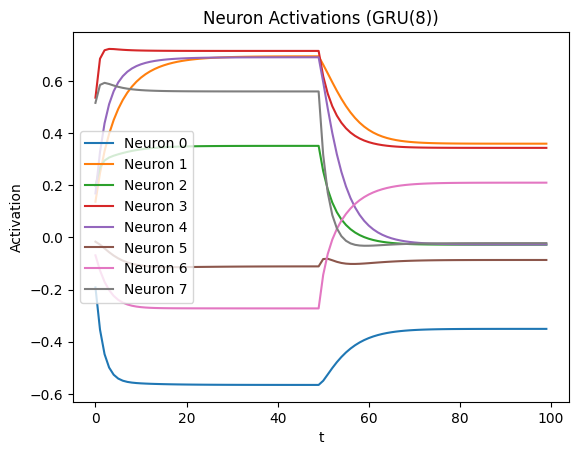

In [19]:
import matplotlib.pyplot as plt
time = np.arange(100)
fig, ax = plt.subplots()
for neuron in range(8):
    ax.plot(time, activations[:, neuron], label=f"Neuron {neuron}")
ax.legend()
ax.set_xlabel('t')
ax.set_ylabel('Activation')
ax.set_title('Neuron Activations (GRU(8))')
plt.show()

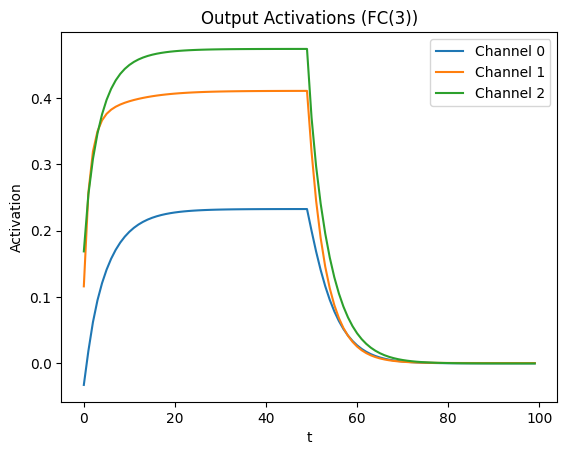

In [20]:
fig, ax = plt.subplots()
time = np.arange(100)
for output in range(3):
    ax.plot(time, out[0, :, output].cpu().detach().numpy(), label=f"Channel {output}")
ax.legend()
ax.set_xlabel('t')
ax.set_ylabel('Activation')
ax.set_title('Output Activations (FC(3))')
plt.show()